# Notebook 7 — Exploratory Ecological Risk Proxy

This notebook adds a small, defensible ecological component to the FEMA/NRI thesis pipeline. It does **not** claim to model ecological loss directly. Instead, it constructs an exploratory ecological exposure/risk proxy by combining predicted wildfire risk with natural vegetation exposure.

Main idea:

\[
\text{Ecological risk proxy} = \text{Predicted wildfire risk percentile} \times \text{Natural vegetation fraction}
\]

where natural vegetation fraction is derived from forest, shrub, and grass land-cover fractions.


In [1]:

# ============================================================
# Cell 1 — Imports and export setup
# ============================================================
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

EXPORT_DIR = Path("/content/thesis_exports/notebook7_ecological_proxy_no_titles")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Export directory:", EXPORT_DIR)


Export directory: /content/thesis_exports/notebook7_ecological_proxy_no_titles


In [2]:

# ============================================================
# Cell 2 — Helper functions for clean no-title exports
# ============================================================

def _format_value(x):
    """Readable formatting for table cells."""
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return f"{x:,}"
    if isinstance(x, (float, np.floating)):
        ax = abs(x)
        if ax >= 1_000_000:
            return f"{x:,.0f}"
        if ax >= 1_000:
            return f"{x:,.2f}"
        if ax >= 10:
            return f"{x:,.2f}"
        return f"{x:,.4f}"
    return str(x)


def save_dataframe_as_pdf_no_title(df, filename, rows_per_page=25, fontsize=7, fig_width=14, row_height=0.38):
    """Save a DataFrame as a multi-page PDF table without a title."""
    path = EXPORT_DIR / filename
    df_to_save = df.copy()

    for col in df_to_save.columns:
        df_to_save[col] = df_to_save[col].apply(_format_value)

    with PdfPages(path) as pdf:
        for start in range(0, len(df_to_save), rows_per_page):
            page_df = df_to_save.iloc[start:start + rows_per_page]
            fig_height = max(4.0, row_height * len(page_df) + 1.2)
            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            ax.axis("off")

            table = ax.table(
                cellText=page_df.values,
                colLabels=page_df.columns,
                cellLoc="center",
                loc="center"
            )
            table.auto_set_font_size(False)
            table.set_fontsize(fontsize)
            table.scale(1, 1.25)

            for key, cell in table.get_celld().items():
                cell.set_linewidth(0.4)
                if key[0] == 0:
                    cell.set_text_props(weight="bold")
                    cell.set_facecolor("#eeeeee")

            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print("Saved table PDF:", path)
    return path


def save_current_figure(fig, pdf_name, png_name=None, dpi=300):
    """Save current matplotlib figure as PDF and PNG."""
    pdf_path = EXPORT_DIR / pdf_name
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved figure PDF:", pdf_path)
    if png_name is not None:
        png_path = EXPORT_DIR / png_name
        fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
        print("Saved figure PNG:", png_path)
    return pdf_path


In [3]:
# ============================================================
# Cell 3 — Load the final combined FEMA/NRI + environmental CONUS dataset
# Flexible version for Notebook 5 exported file
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = "/content/nri_wildfire_county_model_env_conus.csv"

final_df = pd.read_csv(DATA_PATH)

# Clean column names
final_df.columns = [c.strip() for c in final_df.columns]

print("Loaded:", DATA_PATH)
print("Shape:", final_df.shape)
print("\nColumns in file:")
for c in final_df.columns:
    print(c)

# ------------------------------------------------------------
# Helper function: rename first matching column to standard name
# ------------------------------------------------------------
def rename_first_match(df, standard_name, candidates):
    if standard_name in df.columns:
        return df
    for c in candidates:
        if c in df.columns:
            return df.rename(columns={c: standard_name})
    return df

# ------------------------------------------------------------
# Standardize likely column names
# ------------------------------------------------------------
final_df = rename_first_match(final_df, "state", [
    "STATE", "state_name", "STATE_NAME", "stname", "STNAME"
])

final_df = rename_first_match(final_df, "county", [
    "COUNTY", "county_name", "COUNTY_NAME", "countyname", "COUNTYNAME", "NAME"
])

final_df = rename_first_match(final_df, "county_fips", [
    "fips", "FIPS", "GEOID", "geoid", "STCOFIPS", "stcofips", "county_geoid"
])

final_df = rename_first_match(final_df, "wildfire_eal", [
    "WFIR_EAL", "wfir_eal", "WILDFIRE_EAL", "wildfire_expected_annual_loss",
    "expected_annual_loss", "eal", "EAL"
])

final_df = rename_first_match(final_df, "log_wildfire_eal", [
    "log_WFIR_EAL", "log_wfir_eal", "log_eal", "log_expected_annual_loss"
])

final_df = rename_first_match(final_df, "forest_fraction", [
    "forest_frac", "frac_forest", "forest", "nlcd_forest_fraction",
    "forest_area_fraction"
])

final_df = rename_first_match(final_df, "shrub_fraction", [
    "shrub_frac", "frac_shrub", "shrub", "nlcd_shrub_fraction",
    "shrub_area_fraction"
])

final_df = rename_first_match(final_df, "grass_fraction", [
    "grass_frac", "frac_grass", "grass", "grassland_fraction",
    "nlcd_grass_fraction", "grass_area_fraction"
])

final_df = rename_first_match(final_df, "developed_fraction", [
    "developed_frac", "frac_developed", "developed", "nlcd_developed_fraction",
    "developed_area_fraction"
])

# ------------------------------------------------------------
# Create log target if missing
# ------------------------------------------------------------
if "log_wildfire_eal" not in final_df.columns and "wildfire_eal" in final_df.columns:
    final_df["log_wildfire_eal"] = np.log1p(final_df["wildfire_eal"])

# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------
required_basic = ["state", "county", "county_fips", "wildfire_eal", "log_wildfire_eal"]
required_env = ["forest_fraction", "shrub_fraction", "grass_fraction"]

missing_cols = [c for c in required_basic + required_env if c not in final_df.columns]

if missing_cols:
    print("\nStill missing required columns:")
    print(missing_cols)
    print("\nAvailable columns:")
    print(list(final_df.columns))
    raise ValueError("Some required columns are still missing. Check the printed column names and add aliases above.")

# Ensure FIPS is string
final_df["county_fips"] = final_df["county_fips"].astype(str).str.zfill(5)

print("\nFinal standardized dataframe shape:", final_df.shape)
print("\nRequired columns found successfully.")
display(final_df.head())

Loaded: /content/nri_wildfire_county_model_env_conus.csv
Shape: (3163, 27)

Columns in file:
state
county
county_fips
wildfire_eal
log_wildfire_eal
population
building_value
agriculture_value
area_sq_mi
social_vulnerability_score
community_resilience_score
population_density
building_value_density
agriculture_value_density
building_value_per_capita
state_fips
county_name_ee
developed_frac
elevation_m
forest_frac
grass_frac
shrub_frac
slope_deg
warm_pr_mm
warm_tmmx_c
warm_vpd_kpa
warm_wind_ms

Final standardized dataframe shape: (3163, 27)

Required columns found successfully.


,state,county,county_fips,wildfire_eal,log_wildfire_eal,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,...,developed_fraction,elevation_m,forest_fraction,grass_fraction,shrub_fraction,slope_deg,warm_pr_mm,warm_tmmx_c,warm_vpd_kpa,warm_wind_ms
0,Alabama,Autauga,01001,3.626224e+04,10.498560,58764,1.024141e+10,27630646.0,610.470508,38.040712,...,0.064990,112.932212,0.498794,0.210785,0.069525,3.605567,4.283579,30.626405,1.086097,2.892774
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,231365,5.160230e+10,155012958.0,2047.738775,44.243003,...,0.071507,29.697682,0.269194,0.088107,0.037410,1.753440,5.840063,30.504150,0.977747,3.574369
2,Alabama,Barbour,01005,2.590932e+04,10.162397,25160,5.441822e+09,135914589.0,913.646511,96.374046,...,0.040160,122.694949,0.565439,0.129400,0.104817,3.277155,4.034570,31.028851,1.124024,2.973741
3,Alabama,Bibb,01007,3.260612e+04,10.392286,22239,3.532631e+09,5410008.0,632.486798,75.254453,...,0.051353,130.060354,0.703750,0.101765,0.068850,4.513809,3.721240,30.542362,1.116948,2.954657
4,Alabama,Blount,01009,9.336726e+04,11.444307,58992,8.773489e+09,312712010.0,657.196555,69.338422,...,0.078889,243.877604,0.551044,0.311285,0.026850,5.688653,3.890174,29.051662,1.006516,2.854285


In [4]:
# ============================================================
# Cell 4 — Build final predicted wildfire EAL values
# Corrected version using actual column names in Notebook 5 file
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# Full combined feature set using actual column names in nri_wildfire_county_model_env_conus.csv
combined_feature_cols = [
    "population",
    "building_value",
    "agriculture_value",
    "area_sq_mi",
    "social_vulnerability_score",
    "community_resilience_score",
    "population_density",
    "building_value_density",
    "agriculture_value_density",
    "building_value_per_capita",
    "elevation_m",
    "slope_deg",
    "forest_fraction",
    "shrub_fraction",
    "grass_fraction",
    "developed_fraction",
    "warm_tmmx_c",
    "warm_pr_mm",
    "warm_wind_ms",
    "warm_vpd_kpa"
]

combined_feature_cols = [c for c in combined_feature_cols if c in final_df.columns]

print("Available combined features:", len(combined_feature_cols))
print(combined_feature_cols)

if len(combined_feature_cols) < 18:
    print("WARNING: Fewer than expected combined features were found. Please check column names.")

# Force regenerate predictions using the corrected full feature set
model_df = final_df.dropna(subset=["wildfire_eal", "log_wildfire_eal"]).copy()

X_all = model_df[combined_feature_cols]
y_all = model_df["log_wildfire_eal"]

final_rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ))
])

final_rf_pipeline.fit(X_all, y_all)

model_df["predicted_log_wildfire_eal"] = final_rf_pipeline.predict(X_all)
model_df["predicted_wildfire_eal"] = np.expm1(model_df["predicted_log_wildfire_eal"]).clip(lower=0)

final_df = model_df.copy()

# Percentile rank based on predicted wildfire EAL
final_df["predicted_risk_percentile"] = (
    final_df["predicted_wildfire_eal"].rank(pct=True) * 100
)

# Risk categories based on predicted percentiles
final_df["predicted_risk_category"] = pd.cut(
    final_df["predicted_risk_percentile"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"],
    include_lowest=True
)

print(final_df[[
    "state",
    "county",
    "wildfire_eal",
    "predicted_wildfire_eal",
    "predicted_risk_percentile"
]].head())

Available combined features: 20
['population', 'building_value', 'agriculture_value', 'area_sq_mi', 'social_vulnerability_score', 'community_resilience_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita', 'elevation_m', 'slope_deg', 'forest_fraction', 'shrub_fraction', 'grass_fraction', 'developed_fraction', 'warm_tmmx_c', 'warm_pr_mm', 'warm_wind_ms', 'warm_vpd_kpa']
     state   county  wildfire_eal  predicted_wildfire_eal  \
0  Alabama  Autauga  3.626224e+04            4.545910e+04   
1  Alabama  Baldwin  1.500314e+06            1.144757e+06   
2  Alabama  Barbour  2.590932e+04            2.902314e+04   
3  Alabama     Bibb  3.260612e+04            2.910877e+04   
4  Alabama   Blount  9.336726e+04            1.055268e+05   

   predicted_risk_percentile  
0                  51.944357  
1                  91.811571  
2                  43.534619  
3                  43.661081  
4                  66.044894  


In [5]:

# ============================================================
# Cell 5 — Construct ecological exposure and ecological risk proxy
# ============================================================
# This is an ecological exposure/risk proxy, not a direct ecological-loss target.

frac_cols = ["forest_fraction", "shrub_fraction", "grass_fraction", "developed_fraction"]
for col in frac_cols:
    if col in final_df.columns:
        print(col, "min=", final_df[col].min(), "max=", final_df[col].max())

# Normalize land-cover fractions to 0--1 if they appear to be percentages.
def normalize_fraction(s):
    s = pd.to_numeric(s, errors="coerce")
    if s.max(skipna=True) > 1.5:
        return s / 100.0
    return s

final_df["forest_fraction_01"] = normalize_fraction(final_df["forest_fraction"])
final_df["shrub_fraction_01"] = normalize_fraction(final_df["shrub_fraction"])
final_df["grass_fraction_01"] = normalize_fraction(final_df["grass_fraction"])

if "developed_fraction" in final_df.columns:
    final_df["developed_fraction_01"] = normalize_fraction(final_df["developed_fraction"])
else:
    final_df["developed_fraction_01"] = np.nan

# Natural vegetation exposure proxy
final_df["natural_vegetation_fraction"] = (
    final_df["forest_fraction_01"].fillna(0) +
    final_df["shrub_fraction_01"].fillna(0) +
    final_df["grass_fraction_01"].fillna(0)
).clip(lower=0, upper=1)

# Ecological risk proxy: economic risk percentile weighted by natural vegetation exposure
final_df["ecological_risk_proxy"] = (
    final_df["predicted_risk_percentile"] * final_df["natural_vegetation_fraction"]
)

final_df["ecological_risk_percentile"] = final_df["ecological_risk_proxy"].rank(pct=True) * 100
final_df["ecological_risk_category"] = pd.cut(
    final_df["ecological_risk_percentile"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"],
    include_lowest=True
)

summary_cols = [
    "natural_vegetation_fraction", "predicted_risk_percentile",
    "ecological_risk_proxy", "ecological_risk_percentile"
]
print(final_df[summary_cols].describe())
display(final_df[["state", "county"] + summary_cols + ["ecological_risk_category"]].head())


forest_fraction min= 0.0 max= 0.9273616334928972
shrub_fraction min= 0.0 max= 0.9714889649845057
grass_fraction min= 3.806931257346537e-05 max= 0.9763166867776834
developed_fraction min= 0.001797757531009 max= 0.9253268414840532
       natural_vegetation_fraction  predicted_risk_percentile  \
count                  3163.000000                3163.000000   
mean                      0.566938                  50.015808   
std                       0.300787                  28.872076   
min                       0.000000                   0.031616   
25%                       0.296727                  25.023712   
50%                       0.620078                  50.015808   
75%                       0.846947                  75.007904   
max                       0.995431                 100.000000   

       ecological_risk_proxy  ecological_risk_percentile  
count            3163.000000                 3163.000000  
mean               30.962363                   50.015808  
std     

,state,county,natural_vegetation_fraction,predicted_risk_percentile,ecological_risk_proxy,ecological_risk_percentile,ecological_risk_category
0,Alabama,Autauga,0.779104,51.944357,40.470041,68.131521,High
1,Alabama,Baldwin,0.394711,91.811571,36.238999,64.653810,High
2,Alabama,Barbour,0.799656,43.534619,34.812708,63.199494,High
3,Alabama,Bibb,0.874365,43.661081,38.175728,66.202972,High
4,Alabama,Blount,0.889179,66.044894,58.725745,82.200443,Very High


In [6]:

# ============================================================
# Cell 6 — Export Table 1: Ecological proxy definition
# ============================================================
proxy_definition = pd.DataFrame({
    "Component": [
        "Forest fraction",
        "Shrub fraction",
        "Grass fraction",
        "Natural vegetation fraction",
        "Predicted risk percentile",
        "Ecological risk proxy",
        "Ecological risk category"
    ],
    "Definition": [
        "County fraction covered by forest land cover",
        "County fraction covered by shrub land cover",
        "County fraction covered by grass land cover",
        "Forest fraction + shrub fraction + grass fraction",
        "Percentile rank of predicted wildfire EAL",
        "Predicted risk percentile multiplied by natural vegetation fraction",
        "Percentile-based category of ecological risk proxy"
    ],
    "Interpretation": [
        "Natural vegetation exposure",
        "Natural vegetation exposure",
        "Natural vegetation exposure",
        "Approximate natural ecosystem exposure at county level",
        "Economic wildfire risk signal from the final FEMA/NRI model",
        "Overlap of predicted wildfire risk and natural vegetation exposure",
        "Screening class for exploratory ecological wildfire-risk assessment"
    ]
})

display(proxy_definition)
save_dataframe_as_pdf_no_title(
    proxy_definition,
    "table_1_ecological_proxy_definition.pdf",
    rows_per_page=20,
    fontsize=7,
    fig_width=14,
    row_height=0.42
)


,Component,Definition,Interpretation
0,Forest fraction,County fraction covered by forest land cover,Natural vegetation exposure
1,Shrub fraction,County fraction covered by shrub land cover,Natural vegetation exposure
2,Grass fraction,County fraction covered by grass land cover,Natural vegetation exposure
3,Natural vegetation fraction,Forest fraction + shrub fraction + grass fraction,Approximate natural ecosystem exposure at coun...
4,Predicted risk percentile,Percentile rank of predicted wildfire EAL,Economic wildfire risk signal from the final F...
5,Ecological risk proxy,Predicted risk percentile multiplied by natura...,Overlap of predicted wildfire risk and natural...
6,Ecological risk category,Percentile-based category of ecological risk p...,Screening class for exploratory ecological wil...


Saved table PDF: /content/thesis_exports/notebook7_ecological_proxy_no_titles/table_1_ecological_proxy_definition.pdf


PosixPath('/content/thesis_exports/notebook7_ecological_proxy_no_titles/table_1_ecological_proxy_definition.pdf')

In [7]:
# ============================================================
# Cell 7 — Export Table 2: Top 25 counties by ecological risk proxy
# Fixed header spacing, no title
# ============================================================

from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

top25_ecological = final_df.sort_values(
    "ecological_risk_proxy",
    ascending=False
).head(25).copy()

# Use normalized fraction columns if available; otherwise use original fraction columns
forest_col = "forest_fraction_01" if "forest_fraction_01" in top25_ecological.columns else "forest_fraction"
shrub_col = "shrub_fraction_01" if "shrub_fraction_01" in top25_ecological.columns else "shrub_fraction"
grass_col = "grass_fraction_01" if "grass_fraction_01" in top25_ecological.columns else "grass_fraction"

export_cols = [
    "state",
    "county",
    "county_fips",
    forest_col,
    shrub_col,
    grass_col,
    "natural_vegetation_fraction",
    "predicted_wildfire_eal",
    "predicted_risk_percentile",
    "ecological_risk_proxy",
    "ecological_risk_category"
]

export_cols = [c for c in export_cols if c in top25_ecological.columns]

top25_export = top25_ecological[export_cols].copy()

# Clean formatting
top25_export["county_fips"] = top25_export["county_fips"].astype(str).str.zfill(5)

for col in [forest_col, shrub_col, grass_col, "natural_vegetation_fraction"]:
    if col in top25_export.columns:
        top25_export[col] = top25_export[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")

if "predicted_wildfire_eal" in top25_export.columns:
    top25_export["predicted_wildfire_eal"] = top25_export["predicted_wildfire_eal"].map(
        lambda x: f"{x:,.0f}" if pd.notna(x) else ""
    )

if "predicted_risk_percentile" in top25_export.columns:
    top25_export["predicted_risk_percentile"] = top25_export["predicted_risk_percentile"].map(
        lambda x: f"{x:.2f}" if pd.notna(x) else ""
    )

if "ecological_risk_proxy" in top25_export.columns:
    top25_export["ecological_risk_proxy"] = top25_export["ecological_risk_proxy"].map(
        lambda x: f"{x:.2f}" if pd.notna(x) else ""
    )

# Clean CSV version without line breaks in headers
csv_export = top25_export.rename(columns={
    "state": "State",
    "county": "County",
    "county_fips": "County FIPS",
    forest_col: "Forest fraction",
    shrub_col: "Shrub fraction",
    grass_col: "Grass fraction",
    "natural_vegetation_fraction": "Natural vegetation fraction",
    "predicted_wildfire_eal": "Predicted wildfire EAL",
    "predicted_risk_percentile": "Predicted risk percentile",
    "ecological_risk_proxy": "Ecological risk proxy",
    "ecological_risk_category": "Ecological risk category"
})

display(csv_export)

csv_path = EXPORT_DIR / "table_2_top25_ecological_risk_proxy_counties.csv"
csv_export.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)

# PDF version with wrapped headers
pdf_export = top25_export.rename(columns={
    "state": "State",
    "county": "County",
    "county_fips": "County\nFIPS",
    forest_col: "Forest\nfraction",
    shrub_col: "Shrub\nfraction",
    grass_col: "Grass\nfraction",
    "natural_vegetation_fraction": "Natural\nvegetation\nfraction",
    "predicted_wildfire_eal": "Predicted\nwildfire\nEAL",
    "predicted_risk_percentile": "Predicted\nrisk\npercentile",
    "ecological_risk_proxy": "Ecological\nrisk\nproxy",
    "ecological_risk_category": "Ecological\nrisk\ncategory"
})

pdf_path = EXPORT_DIR / "table_2_top25_ecological_risk_proxy_counties.pdf"

with PdfPages(pdf_path) as pdf:
    fig, ax = plt.subplots(figsize=(18, 10))
    ax.axis("off")

    col_widths = [
        0.075,  # State
        0.090,  # County
        0.070,  # FIPS
        0.075,  # Forest
        0.075,  # Shrub
        0.075,  # Grass
        0.110,  # Natural vegetation
        0.105,  # Predicted EAL
        0.100,  # Percentile
        0.095,  # Proxy
        0.105   # Category
    ]

    table = ax.table(
        cellText=pdf_export.values,
        colLabels=pdf_export.columns,
        cellLoc="center",
        colLoc="center",
        colWidths=col_widths,
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(7.2)
    table.scale(1.0, 1.45)

    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.45)
        if row == 0:
            cell.set_text_props(weight="bold", fontsize=7.0)
            cell.set_facecolor("#EDEDED")
            cell.set_height(0.075)
        else:
            cell.set_height(0.045)

    pdf.savefig(fig, bbox_inches="tight", pad_inches=0.25)
    plt.close(fig)

print("Saved table PDF:", pdf_path)

,State,County,County FIPS,Forest fraction,Shrub fraction,Grass fraction,Natural vegetation fraction,Predicted wildfire EAL,Predicted risk percentile,Ecological risk proxy,Ecological risk category
1767,New Mexico,Lincoln,35027,0.1244,0.5603,0.3057,0.9904,"7,664,865",97.98,97.04,Very High
80,Arizona,Yavapai,04025,0.1579,0.7712,0.0474,0.9765,"20,276,267",99.37,97.04,Very High
1708,Nevada,Elko,32007,0.0605,0.6652,0.2458,0.9715,"15,797,063",99.05,96.23,Very High
69,Arizona,Coconino,04005,0.2284,0.6181,0.1226,0.9690,"20,168,753",99.30,96.22,Very High
76,Arizona,Navajo,04017,0.1429,0.7070,0.1263,0.9762,"9,334,416",98.29,95.96,Very High
1762,New Mexico,Grant,35017,0.2805,0.4978,0.2037,0.9820,"5,393,697",97.47,95.71,Very High
70,Arizona,Gila,04007,0.3459,0.6019,0.0296,0.9774,"7,569,287",97.91,95.70,Very High
1778,New Mexico,San Miguel,35047,0.2502,0.6506,0.0846,0.9853,"3,982,625",96.93,95.51,Very High
2761,Utah,Washington,49053,0.3237,0.5632,0.0687,0.9556,"28,360,770",99.68,95.26,Very High
516,Idaho,Boise,16015,0.4449,0.3641,0.1748,0.9837,"3,620,263",96.68,95.11,Very High


Saved CSV: /content/thesis_exports/notebook7_ecological_proxy_no_titles/table_2_top25_ecological_risk_proxy_counties.csv
Saved table PDF: /content/thesis_exports/notebook7_ecological_proxy_no_titles/table_2_top25_ecological_risk_proxy_counties.pdf


Saved figure PDF: /content/thesis_exports/notebook7_ecological_proxy_no_titles/figure_1_predicted_eal_vs_natural_vegetation.pdf
Saved figure PNG: /content/thesis_exports/notebook7_ecological_proxy_no_titles/figure_1_predicted_eal_vs_natural_vegetation.png


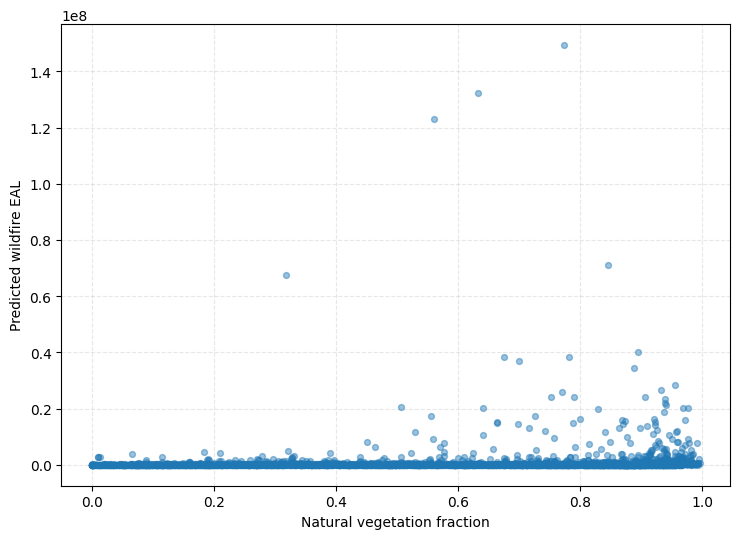

In [8]:

# ============================================================
# Cell 8 — Export Figure 1: Predicted EAL vs natural vegetation fraction
# ============================================================
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(
    final_df["natural_vegetation_fraction"],
    final_df["predicted_wildfire_eal"],
    alpha=0.45,
    s=18
)
ax.set_xlabel("Natural vegetation fraction")
ax.set_ylabel("Predicted wildfire EAL")
ax.grid(alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
plt.tight_layout()

save_current_figure(
    fig,
    "figure_1_predicted_eal_vs_natural_vegetation.pdf",
    "figure_1_predicted_eal_vs_natural_vegetation.png"
)
plt.show()


Saved figure PDF: /content/thesis_exports/notebook7_ecological_proxy_no_titles/figure_2_ecological_risk_proxy_distribution.pdf
Saved figure PNG: /content/thesis_exports/notebook7_ecological_proxy_no_titles/figure_2_ecological_risk_proxy_distribution.png


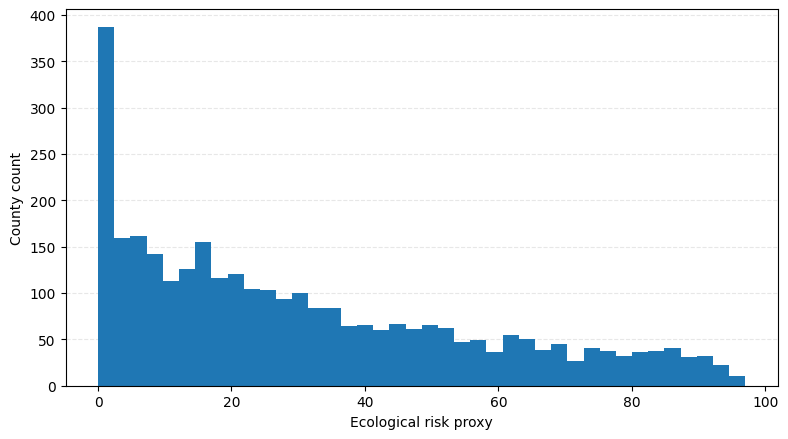

In [9]:

# ============================================================
# Cell 9 — Export Figure 2: Ecological risk proxy distribution
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(final_df["ecological_risk_proxy"].dropna(), bins=40)
ax.set_xlabel("Ecological risk proxy")
ax.set_ylabel("County count")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
plt.tight_layout()

save_current_figure(
    fig,
    "figure_2_ecological_risk_proxy_distribution.pdf",
    "figure_2_ecological_risk_proxy_distribution.png"
)
plt.show()


Saved figure PDF: /content/thesis_exports/notebook7_ecological_proxy_no_titles/figure_3_economic_vs_ecological_risk_quadrants.pdf
Saved figure PNG: /content/thesis_exports/notebook7_ecological_proxy_no_titles/figure_3_economic_vs_ecological_risk_quadrants.png


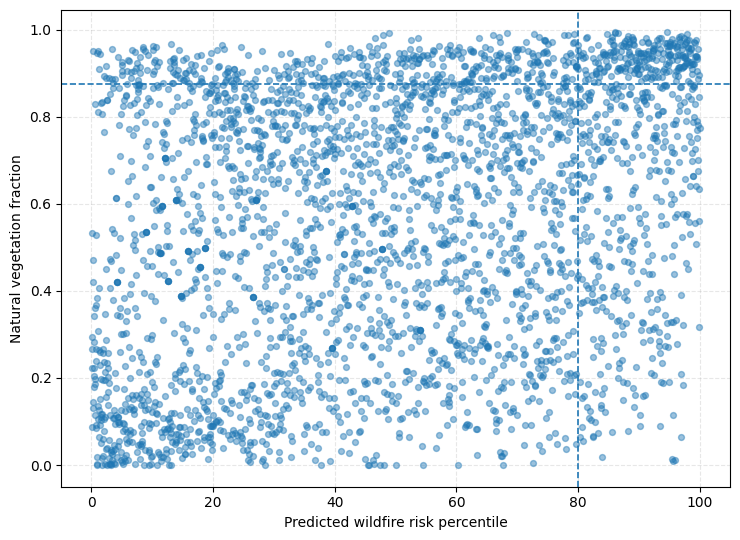

Economic high-risk threshold: 80
Ecological high-exposure threshold: 0.8755490608879936


In [10]:

# ============================================================
# Cell 10 — Export Figure 3: Economic risk vs ecological exposure quadrants
# ============================================================
# High economic risk: predicted risk percentile >= 80
# High ecological exposure: natural vegetation fraction >= 80th percentile

econ_threshold = 80
veg_threshold = final_df["natural_vegetation_fraction"].quantile(0.80)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(
    final_df["predicted_risk_percentile"],
    final_df["natural_vegetation_fraction"],
    alpha=0.45,
    s=18
)
ax.axvline(econ_threshold, linestyle="--", linewidth=1.2)
ax.axhline(veg_threshold, linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicted wildfire risk percentile")
ax.set_ylabel("Natural vegetation fraction")
ax.grid(alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
plt.tight_layout()

save_current_figure(
    fig,
    "figure_3_economic_vs_ecological_risk_quadrants.pdf",
    "figure_3_economic_vs_ecological_risk_quadrants.png"
)
plt.show()

print("Economic high-risk threshold:", econ_threshold)
print("Ecological high-exposure threshold:", veg_threshold)


In [11]:

# ============================================================
# Cell 11 — Save full ecological proxy dataset for Notebook 8
# ============================================================
full_out = EXPORT_DIR / "county_ecological_risk_proxy_full.csv"
final_df.to_csv(full_out, index=False)
print("Saved full ecological proxy dataset:", full_out)
print("Rows:", len(final_df), "Columns:", len(final_df.columns))


Saved full ecological proxy dataset: /content/thesis_exports/notebook7_ecological_proxy_no_titles/county_ecological_risk_proxy_full.csv
Rows: 3163 Columns: 39
